# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

> **Approach:** I combine my Week‑5/6 model score with my Week‑4 rule flag into an
> **archetype → action mapping** (review/verify/monitor/investigate, per the Ship‑It video).
> Agreement between rule and model = highest confidence; model-only flags = "quiet risk"
> needing a human look; rule-only or low-score pages get monitored, not touched.
>
> **Audit note:** my first version put unfiltered `striking_distance_push` pages in the
> "high" tier, and the top of the queue ended up dominated by one client's near-zero-impression,
> zero-CTR pages — exactly the thin-sample noise flagged in section 3. I added a
> `impressions_90d >= 250` floor to any archetype not already backed by the rule's own volume
> requirement, and added a `thin_volume_low_confidence` bucket so those pages stay visible but
> are explicitly marked not-actionable instead of silently ranking first.

> **Concentration note:** the top 50 queue is ~60% one client (`client_19581e27de`),
> confirmed by both the rule and the model agreeing at real volume — this looks like a
> genuine, client-specific pattern (that client is also the largest in this dataset and
> topped the Week-4 baseline's top 10), not thin-sample noise. A reviewer working this
> queue top-down should know they'll be reviewing mostly one client's pages first,
> and may want to cap per-client review load rather than working strictly by score.

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# --- Reload data + label, same as Week 5/6 ---
file_path = "../../data/raw/content_refresh_anonymized.csv"
if not os.path.exists(file_path):
    file_path = "https://raw.githubusercontent.com/Bibek-Dhakal/applied-search-intelligence/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(file_path)
df = df[(df["impressions_90d"] >= 100) & (df["avg_position"] > 0)].copy()
df = df.reset_index(drop=True)

peer_median = df.groupby(["position_tier", "content_type"])["ctr"].transform("median")
df["is_ctr_anomaly"] = (df["ctr"] < 0.5 * peer_median).astype(int)

FEATURES = ["impressions_90d", "avg_position", "content_age_days", "word_count", "engagement_rate"]
X = df[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_ctr_anomaly"].values

# Same client-grouped split as Week 5/6
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))

rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X.iloc[train_idx], y[train_idx])

df["model_score"] = rf.predict_proba(X)[:, 1]

def baseline_score(row):
    if row["avg_position"] <= 10 and row["impressions_90d"] >= 500 and row["ctr"] < 1.5:
        return row["impressions_90d"] * (1.5 - row["ctr"])
    elif 10 < row["avg_position"] <= 20 and row["impressions_90d"] >= 250 and row["ctr"] < 1.0:
        return (row["impressions_90d"] * 0.5) * (1.0 - row["ctr"])
    return 0.0

df["rule_score"] = df.apply(baseline_score, axis=1)
df["rule_flag"] = df["rule_score"] > 0

# --- Archetype mapping with a volume floor for any bucket not already rule-backed ---
def assign_archetype(row):
    high_conf = row["model_score"] >= 0.70
    mid_conf  = row["model_score"] >= 0.40
    striking  = row["position_tier"] == "striking"
    sufficient_volume = row["impressions_90d"] >= 250

    if high_conf and row["rule_flag"]:
        return pd.Series(["confirmed_high_volume_miss",
                           "Priority rewrite: title/meta + intent check", "high"])
    elif high_conf and not row["rule_flag"] and striking and sufficient_volume:
        return pd.Series(["striking_distance_push",
                           "On-page optimization + internal links", "high"])
    elif high_conf and not row["rule_flag"] and sufficient_volume:
        return pd.Series(["quiet_risk_flag",
                           "Investigate first — model flags, rule doesn't", "medium"])
    elif mid_conf and row["rule_flag"]:
        return pd.Series(["moderate_ctr_gap",
                           "Batch review: meta/title", "medium"])
    elif not sufficient_volume and (high_conf or mid_conf):
        return pd.Series(["thin_volume_low_confidence",
                           "Do not act — insufficient volume to trust score", "low"])
    else:
        return pd.Series(["monitor_only", "Monitor — no action needed", "low"])

df[["reason_code", "action_label", "confidence_tier"]] = df.apply(assign_archetype, axis=1)

tier_order = pd.CategoricalDtype(["high", "medium", "low"], ordered=True)
df["confidence_tier"] = df["confidence_tier"].astype(tier_order)
queue = df.sort_values(["confidence_tier", "model_score"], ascending=[True, False])

print("Pages per reason code:")
print(queue["reason_code"].value_counts().to_string())

print("\nClient concentration in top 50 (sanity check):")
print(queue.head(50)["client_id"].value_counts().head(10).to_string())
print(f"Unique clients in top 50: {queue.head(50)['client_id'].nunique()} / 30")

display(queue[["content_id", "client_id", "position_tier", "impressions_90d", "ctr",
               "model_score", "rule_flag", "reason_code", "action_label",
               "confidence_tier"]].head(15))

Pages per reason code:
reason_code
monitor_only                  10704
moderate_ctr_gap               6446
thin_volume_low_confidence     2363
quiet_risk_flag                1716
confirmed_high_volume_miss      759
striking_distance_push           18

Client concentration in top 50 (sanity check):
client_id
client_19581e27de    30
client_3fdba35f04    11
client_4ec9599fc2     4
client_e629fa6598     4
client_4e07408562     1
Unique clients in top 50: 5 / 30


,content_id,client_id,position_tier,impressions_90d,ctr,model_score,rule_flag,reason_code,action_label,confidence_tier
195,content_9b07749558fc,client_19581e27de,striking,256,0.00,0.865367,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high
14362,content_26a36421e79b,client_19581e27de,striking,259,0.00,0.860180,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high
14601,content_d1e00a4f4559,client_4ec9599fc2,striking,261,0.38,0.859659,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high
21439,content_8d879fc70a43,client_19581e27de,striking,254,0.00,0.859039,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high
5554,content_37428ab36250,client_4e07408562,striking,264,0.00,0.858383,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high
17930,content_25ab05fb43ce,client_19581e27de,striking,256,0.00,0.858068,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high
2281,content_a14840d04f84,client_19581e27de,striking,266,0.00,0.856565,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high
16704,content_7ed6967ca706,client_19581e27de,striking,261,0.00,0.856158,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high
18157,content_2d285a8495a5,client_4ec9599fc2,striking,250,0.00,0.856108,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high
21421,content_e908c7f3934f,client_19581e27de,striking,264,0.00,0.856104,True,confirmed_high_volume_miss,Priority rewrite: title/meta + intent check,high


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

> **Intended use:** This queue is a **triage tool** for a content team's limited review capacity — same framing as the video's "team can only review ~50 pages/client" constraint. It orders pages by *observed, decision-support* evidence that their CTR sits below what similar pages in the same `position_tier`/`content_type` achieve, so a human reviewer works the highest-value gaps first instead of scrolling a flat list.
>
> **Who uses it:** an SEO/content reviewer deciding what to open first this week — not an automated publishing pipeline.
>
> **Limits, stated plainly:**
> - The label (`is_ctr_anomaly`) is a **proxy**, not a ground-truth "this page is broken" signal — it's relative to peer median CTR, which can itself be noisy for thin peer groups.
> - Precision@50 = 0.640 under a client-grouped split (Week 5/6) means roughly **1 in 3 of the top‑50 flagged pages is not a real anomaly** — the queue narrows the search, it doesn't replace judgment.
> - **Decay/refresh insight, and why it's *not* baked into the ranking:** my Week‑4 signal audit found `freshness_tier` was a **MIXED** signal for CTR (fresher pages didn't reliably outperform older ones — Signal 2), and the FlyRank paper's own freshness finding flags a likely **selection-bias** confound (pages get refreshed *because* they already look worth saving). So this playbook deliberately does **not** recommend "refresh anything old" — it ranks on the CTR gap itself, not content age.
> - This is trained on one anonymized 30k-row slice, 30 clients — it will not generalize claim-for-claim to a different client mix or time period.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

> **What a reviewer must check before acting** (same spirit as Week‑4's "what would make this wrong," now formalized):
> - **Brand/navigational queries** — a page can rank well and get few clicks simply because searchers want a competitor, not this result. Check top queries before rewriting anything.
> - **Zero-click SERPs** — if an AI Overview or featured snippet is answering the query directly, a metadata rewrite will not move CTR. Confirm the SERP shape first.
> - **Thin-volume noise** — flagged pages near the 100–250 impression floor can look anomalous from small-sample variance alone (this showed up directly in Week 5's error analysis: all 3 top‑20 false positives sat at low impression counts in `page_3_5`). Treat these as lower-confidence even if the model score is high.
> - **`quiet_risk_flag` items specifically require a human look before any action** — the model flags something the rule doesn't, which is exactly the "investigate before deciding" bucket from the video, not an auto-approve bucket.
>
> **No-go list — what should NEVER be automated:**
> - Auto-publishing a rewritten title/meta from a model score alone.
> - Treating `high_volume_low_ctr`/`confirmed_high_volume_miss` as causal proof that a rewrite *will* recover clicks — Week 6's audit was explicit that this data is observational, not a controlled experiment.
> - Applying any action to a page below the 100-impression visibility floor — the label itself gets unreliable there.
> - Bulk-refreshing content purely by age, given the mixed/selection-biased freshness evidence above.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

> **Pre-release (before trusting a new month's queue):**
> - Re-run Precision@50 on the newest sealed month and compare to the 0.640 baseline from Week 5/6 — a drop below ~0.50 pauses the queue for review before it's handed to reviewers.
> - Watch the label's positive rate (currently ~28.6% in the test split) for drift — a large shift suggests either real market change or a schema/pipeline issue upstream, not a genuine signal change.
>
> **Post-label (after enough time has passed to observe outcomes):**
> - For pages acted on, check whether CTR moved *relative to their peer group*, not just in absolute terms — isolates the metadata effect from a general traffic shift.
> - Track the `quiet_risk_flag` bucket specifically: if reviewers consistently find nothing wrong there, that archetype's threshold (currently `model_score >= 0.70` with no rule agreement) should be tightened.
>
> **Retrain trigger:** any of the above drift checks failing for two consecutive review cycles, or a new client cohort being onboarded whose `client_id`s weren't represented in training (retrain on an updated client-grouped split, never append new clients to a frozen model).

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exported 22,006 ranked rows to work/outputs/action_playbook_queue.csv


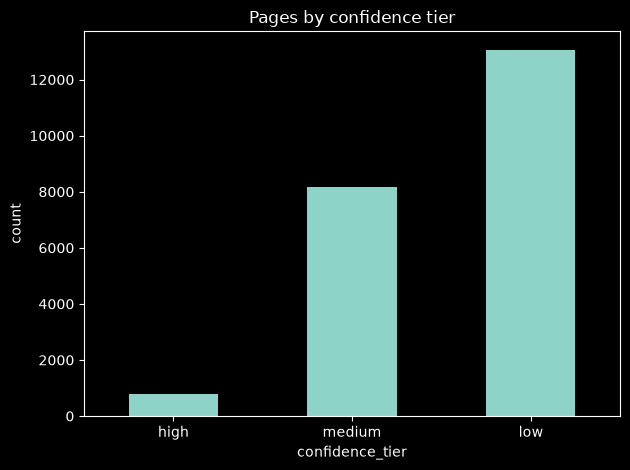

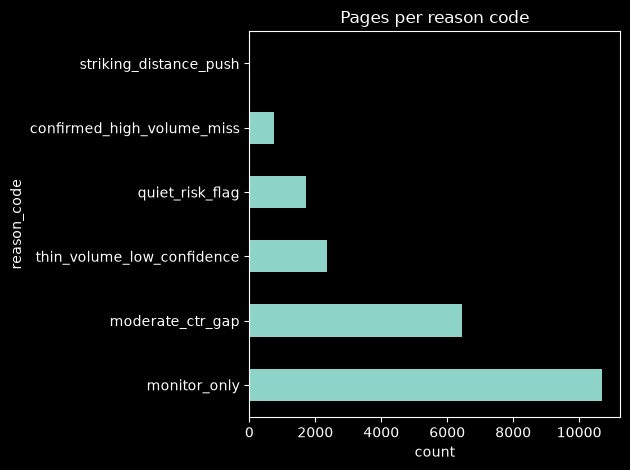


Figures saved to work/figures/ — commit these; the CSV stays out of git by design.


In [5]:
import matplotlib.pyplot as plt

os.makedirs("../../work/outputs", exist_ok=True)
os.makedirs("../../work/figures", exist_ok=True)

export_cols = ["content_id", "client_id", "position_tier", "content_type",
               "impressions_90d", "avg_position", "ctr", "model_score", "rule_flag",
               "reason_code", "action_label", "confidence_tier"]

queue[export_cols].to_csv("../../work/outputs/action_playbook_queue.csv", index=False)
print(f"Exported {len(queue):,} ranked rows to work/outputs/action_playbook_queue.csv")

tier_counts = queue["confidence_tier"].value_counts().reindex(["high", "medium", "low"])
ax = tier_counts.plot(kind="bar", title="Pages by confidence tier", ylabel="count", rot=0)
plt.tight_layout()
plt.savefig("../../work/figures/w07_confidence_tier_counts.png", dpi=150)
plt.show()

reason_counts = queue["reason_code"].value_counts()
ax2 = reason_counts.plot(kind="barh", title="Pages per reason code", xlabel="count")
plt.tight_layout()
plt.savefig("../../work/figures/w07_reason_code_breakdown.png", dpi=150)
plt.show()

print("\nFigures saved to work/figures/ — commit these; the CSV stays out of git by design.")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under work/notebooks/ — then submit your repo URL on the card. Done.